<a href="https://colab.research.google.com/github/aarti-raut/AML-Lab-Experiments/blob/main/Experiment_02_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 2: Decision Tree Classifier
**Dataset:** Iris Dataset (UCI ML Repository)
**Aim:** Train the system using Iris dataset and determine accuracy using Decision Tree.

In [1]:
# Import libraries
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

print('Dataset loaded: Iris')
print(f'Total samples: {X.shape[0]}, Features: {X.shape[1]}')
print(f'Classes: {iris.target_names}')


Dataset loaded: Iris
Total samples: 150, Features: 4
Classes: ['setosa' 'versicolor' 'virginica']


In [2]:
# Preprocessing: Scale + Split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')


Training samples: 120
Testing samples:  30


In [3]:
# Train Decision Tree model
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

print('Decision Tree model trained successfully!')
print(f'Tree Depth: {dt_model.get_depth()}')
print(f'Number of Leaves: {dt_model.get_n_leaves()}')


Decision Tree model trained successfully!
Tree Depth: 3
Number of Leaves: 5


In [4]:
# Predict and Evaluate
y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'=== Model Accuracy: {accuracy * 100:.2f}% ===')

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

print('=== Confusion Matrix ===')
print(confusion_matrix(y_test, y_pred))


=== Model Accuracy: 100.00% ===

=== Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

=== Confusion Matrix ===
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


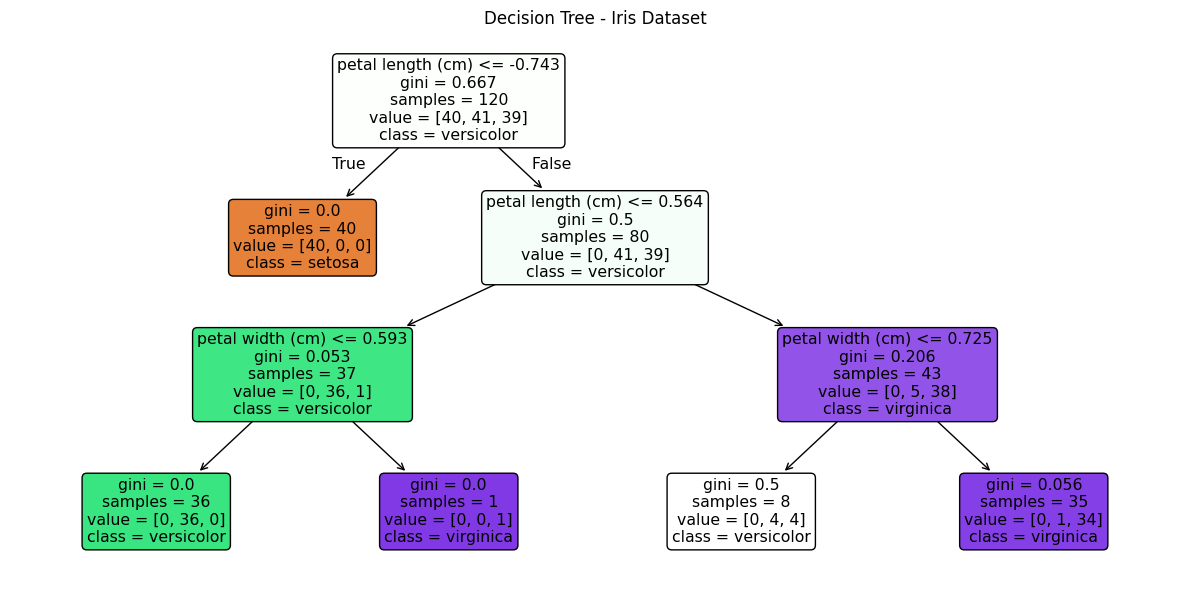

In [5]:
# Visualize the Decision Tree
plt.figure(figsize=(12, 6))
tree.plot_tree(dt_model, feature_names=iris.feature_names,
               class_names=iris.target_names, filled=True, rounded=True)
plt.title('Decision Tree - Iris Dataset')
plt.tight_layout()
plt.show()
